In [1]:
# First, install the neuralforecast package
#!pip install neuralforecast

import pandas as pd
from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS
from neuralforecast.losses.pytorch import MAE


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('fromCale/netherland_hourly.csv')
df.head()

,utc_timestamp,cet_cest_timestamp,NL_load_actual_entsoe_transparency,NL_load_forecast_entsoe_transparency
0,2014-12-31T23:00:00Z,2015-01-01T00:00:00+0100,NaN,NaN
1,2015-01-01T00:00:00Z,2015-01-01T01:00:00+0100,9401.0,8937.0
2,2015-01-01T01:00:00Z,2015-01-01T02:00:00+0100,8957.0,8608.0
3,2015-01-01T02:00:00Z,2015-01-01T03:00:00+0100,8462.0,8462.0
4,2015-01-01T03:00:00Z,2015-01-01T04:00:00+0100,8156.0,8500.0


## Training

In [3]:
# Select data for training # 
fra = '2018-01-01'
til = '2018-11-01'
# Using between method (inclusive of both endpoints)
#data_2018 = df.loc[df['utc_timestamp'].between('2015-01-01', '2015-03-01')]
trainData = df.loc[(df['utc_timestamp'] >= fra) & (df['utc_timestamp'] <= til)]
trainData = trainData.rename(columns={'utc_timestamp': 'ds', 'NL_load_actual_entsoe_transparency': 'y'})
trainData['unique_id'] = 'METER_01' # Identitas unik
trainData = trainData[['unique_id', 'ds', 'y']]
trainData['ds'] = pd.to_datetime(trainData['ds'])
trainData

,unique_id,ds,y
26305,METER_01,2018-01-01 00:00:00+00:00,10690.0
26306,METER_01,2018-01-01 01:00:00+00:00,10354.0
26307,METER_01,2018-01-01 02:00:00+00:00,10032.0
26308,METER_01,2018-01-01 03:00:00+00:00,9766.0
26309,METER_01,2018-01-01 04:00:00+00:00,9768.0
...,...,...,...
33596,METER_01,2018-10-31 19:00:00+00:00,15350.0
33597,METER_01,2018-10-31 20:00:00+00:00,14275.0
33598,METER_01,2018-10-31 21:00:00+00:00,13134.0
33599,METER_01,2018-10-31 22:00:00+00:00,12158.0


In [4]:
len(trainData)

7296

## Validatian


In [5]:
# Select data for validation # 
fra = '2018-11-01'
til = '2018-12-01'
# Using between method (inclusive of both endpoints)
#data_2018 = df.loc[df['utc_timestamp'].between('2015-01-01', '2015-03-01')]
validData = df.loc[(df['utc_timestamp'] >= fra) & (df['utc_timestamp'] <= til)]
validData = validData.rename(columns={'utc_timestamp': 'ds', 'NL_load_actual_entsoe_transparency': 'actual'})
validData

,ds,cet_cest_timestamp,actual,NL_load_forecast_entsoe_transparency
33601,2018-11-01T00:00:00Z,2018-11-01T01:00:00+0100,10722.0,11382.0
33602,2018-11-01T01:00:00Z,2018-11-01T02:00:00+0100,10563.0,11072.0
33603,2018-11-01T02:00:00Z,2018-11-01T03:00:00+0100,10540.0,10977.0
33604,2018-11-01T03:00:00Z,2018-11-01T04:00:00+0100,10584.0,11034.0
33605,2018-11-01T04:00:00Z,2018-11-01T05:00:00+0100,11084.0,11475.0
...,...,...,...,...
34316,2018-11-30T19:00:00Z,2018-11-30T20:00:00+0100,15119.0,15692.0
34317,2018-11-30T20:00:00Z,2018-11-30T21:00:00+0100,14163.0,14656.0
34318,2018-11-30T21:00:00Z,2018-11-30T22:00:00+0100,13154.0,13595.0
34319,2018-11-30T22:00:00Z,2018-11-30T23:00:00+0100,12444.0,12779.0


## Forecast

In [6]:
# 3. Konfigurasi Model
# h: berapa langkah ke depan yang ingin diprediksi
# input_size: berapa langkah ke belakang yang dilihat model
horizon = len(validData)  # Contoh: prediksi 24 jam ke depan
model = NHITS(
    h=horizon,
    input_size=len(trainData), 
    start_padding_enabled=True,  # Melihat tren 1 minggu terakhir
    loss=MAE(),                  # Metrik evaluasi
    max_steps=1000,               # Jumlah training iterations
    n_freq_downsample=[24, 12, 1], # Menangkap pola harian, 12-jam, dan jam-jaman
    early_stop_patience_steps=10  # Berhenti jika akurasi tidak membaik
)


Seed set to 1


In [7]:
# 4. Inisialisasi dan Training

nf = NeuralForecast(models=[model], freq='H')
nf.fit(df=trainData, val_size=horizon)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │ 21.5 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 21.5 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 21.5 M                                                                                               
Total estimated model params size (MB): 85                                                                         
Modules in train mode: 34                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/opt/anaconda3/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, 
LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

`Trainer.fit` stopped: `max_steps=1000` reached.


In [8]:
# 5. Forecasting
fcst_df = nf.predict()
fcst_df


/opt/anaconda3/lib/python3.13/site-packages/utilsforecast/processing.py:378: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/opt/anaconda3/lib/python3.13/site-packages/utilsforecast/processing.py:434: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

/opt/anaconda3/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


,unique_id,ds,NHITS
0,METER_01,2018-11-01 00:00:00+00:00,12314.430664
1,METER_01,2018-11-01 01:00:00+00:00,12314.407227
2,METER_01,2018-11-01 02:00:00+00:00,12314.390625
3,METER_01,2018-11-01 03:00:00+00:00,12314.403320
4,METER_01,2018-11-01 04:00:00+00:00,12314.426758
...,...,...,...
715,METER_01,2018-11-30 19:00:00+00:00,9532.673828
716,METER_01,2018-11-30 20:00:00+00:00,9532.647461
717,METER_01,2018-11-30 21:00:00+00:00,9532.614258
718,METER_01,2018-11-30 22:00:00+00:00,9532.681641


# Merge DataFrame

In [9]:
# Convert the 'ds' column in both DataFrames to the same data type (datetime)
fcst_df['ds'] = pd.to_datetime(fcst_df['ds'])
validData['ds'] = pd.to_datetime(validData['ds'])

# Now merge the DataFrames
result = pd.merge(fcst_df, validData, on='ds', how='inner')

In [10]:
result

,unique_id,ds,NHITS,cet_cest_timestamp,actual,NL_load_forecast_entsoe_transparency
0,METER_01,2018-11-01 00:00:00+00:00,12314.430664,2018-11-01T01:00:00+0100,10722.0,11382.0
1,METER_01,2018-11-01 01:00:00+00:00,12314.407227,2018-11-01T02:00:00+0100,10563.0,11072.0
2,METER_01,2018-11-01 02:00:00+00:00,12314.390625,2018-11-01T03:00:00+0100,10540.0,10977.0
3,METER_01,2018-11-01 03:00:00+00:00,12314.403320,2018-11-01T04:00:00+0100,10584.0,11034.0
4,METER_01,2018-11-01 04:00:00+00:00,12314.426758,2018-11-01T05:00:00+0100,11084.0,11475.0
...,...,...,...,...,...,...
715,METER_01,2018-11-30 19:00:00+00:00,9532.673828,2018-11-30T20:00:00+0100,15119.0,15692.0
716,METER_01,2018-11-30 20:00:00+00:00,9532.647461,2018-11-30T21:00:00+0100,14163.0,14656.0
717,METER_01,2018-11-30 21:00:00+00:00,9532.614258,2018-11-30T22:00:00+0100,13154.0,13595.0
718,METER_01,2018-11-30 22:00:00+00:00,9532.681641,2018-11-30T23:00:00+0100,12444.0,12779.0


In [11]:

import numpy as np
# 1. Calculate the Mean of Actual Values (Denominator)
y_mean = np.mean(result['actual'])

# 2. Calculate rMAE (Relative Mean Absolute Error)
mae = np.mean(np.abs(result['actual'] - result['NHITS']))
rmae = mae / y_mean

# 3. Calculate rRMSE (Relative Root Mean Square Error)
rmse = np.sqrt(np.mean((result['actual'] - result['NHITS'])**2))
rrmse = rmse / y_mean

metricResult = f'rRMSE: {rrmse:.4f} rMAE: {rmae:.4f} '
print(metricResult)



rRMSE: 0.2928 rMAE: 0.2503 


In [12]:
city = 'Hourly The Netherland NHITS'

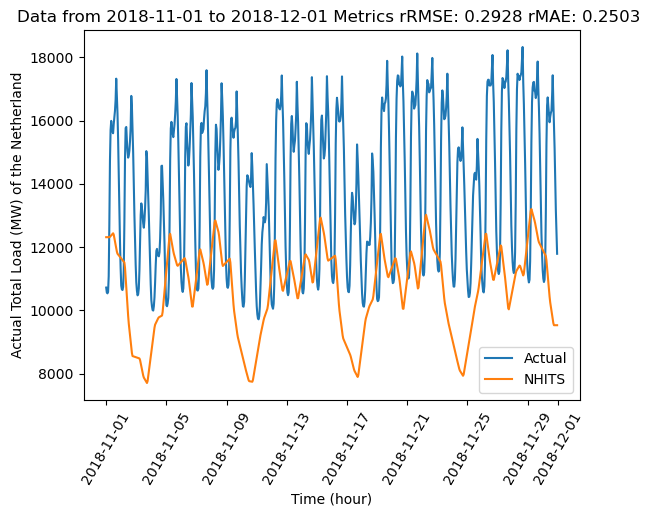

In [13]:
# plot Result dan save

plt.plot(result['ds'], result['actual'], label='Actual')
plt.plot(result['ds'], result['NHITS'],label='NHITS')
#plt.plot(fcst_df['ds'], fcst_df['TimeGPT-hi-80'])

# Menambahkan label sumbu dan judul plot
plt.xlabel('Time (hour)')
plt.xticks(rotation=60)  # Rotate labels by 45 degrees
plt.ylabel('Actual Total Load (MW) of the Netherland')
#plt.title('Plot of Combined Value over Date')
plt.title(f'Data from {fra} to {til} Metrics {metricResult}')


# Menambahkan legenda
plt.legend()

# Mengganti spasi dan karakter khusus dengan garis bawah
#result_cleaned = result.replace(' ', '_').replace(':', '_')

# Menyimpan plot ke file gambar dengan judul yang diperbarui
#plt.savefig(f'./time_gpt/result_pure_time_gpt_{result_cleaned}.png')
plt.savefig(f'Plot {city} from {fra} to {til} metric {metricResult}.png', dpi=300, bbox_inches='tight')

# Menampilkan plot
plt.show()
